<a href="https://colab.research.google.com/github/hawa1983/MG-628/blob/main/SalesTimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## SECTION 1: Load & Visualize Data

The time series plot shows the behavior of sales over time, allowing us to visually identify patterns such as trend, seasonality, and variability. The data appears to follow an overall upward trend, indicating that sales are increasing over time. There are also repeating fluctuations, suggesting the presence of seasonality, where certain months consistently experience higher or lower sales. Additionally, there is some month-to-month variability, which may be caused by random factors or noise in the data. This visualization provides an important foundation for further analysis using smoothing and modeling techniques.

## 1. Libraries and data loading

In [15]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
# Load data
df = pd.read_csv("https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/sales_data(1).csv")

# Prepare date column
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df = df.set_index("Date")
df = df.asfreq("ME")

# Check data
print(df.head())
print(df.info())
print(df.describe())

                 Sales
Date                  
2000-01-31  102.483571
2000-02-29  103.418884
2000-03-31  111.151860
2000-04-30  118.748142
2000-05-31  112.379223
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 200 entries, 2000-01-31 to 2016-08-31
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   200 non-null    float64
dtypes: float64(1)
memory usage: 3.1 KB
None
            Sales
count  200.000000
mean   199.796145
std     58.613069
min     95.289837
25%    149.318193
50%    197.991738
75%    249.269017
max    299.076185


## 2. Introduction to time series and basic visualization

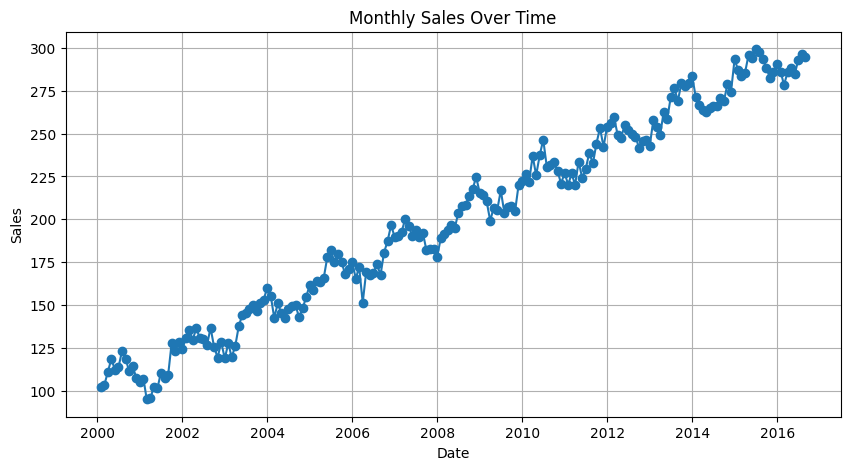

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/sales_data(1).csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Plot time series
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Sales'], marker='o', linestyle='-')
plt.title("Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

**Time Series Analysis of Monthly Sales**

1. Purpose
   The purpose of this analysis is to examine the monthly sales data over time in order to identify key patterns such as trend, seasonality, and variability. Understanding these components helps determine whether sales are growing, how demand fluctuates throughout the year, and whether the data is suitable for forecasting. This analysis provides a foundation for applying time series models and making informed business decisions.

2. Trend
   The time series shows a clear and consistent upward trend over the observed period. Sales increase steadily from approximately 100 at the beginning to nearly 300 by the end of the series. This indicates sustained growth in the business and suggests that demand for the product or service is increasing over time.

3. Seasonality
   The data exhibits strong seasonal patterns, with regular peaks and troughs occurring at consistent intervals. These repeating cycles suggest that certain months consistently experience higher sales, while others experience lower sales. The presence of this pattern indicates predictable fluctuations in demand throughout each year.

4. Variability (Noise)
   There is noticeable short-term variability in the data, reflected in the small fluctuations around the overall trend. However, this variability is relatively minor compared to the dominant trend and seasonal components. This suggests that most of the changes in sales can be explained by systematic patterns rather than random variation.

5. Amplitude of Fluctuations
   The magnitude of the fluctuations increases slightly over time as the level of sales rises. This indicates that variability may scale with the size of sales, meaning that higher sales levels are associated with larger absolute changes. This behavior is commonly observed in real-world time series data.

6. Stationarity
   The time series is non-stationary because both the mean and variance change over time. The upward trend and seasonal patterns violate the assumption of constant statistical properties. As a result, the data may require transformation or differencing before applying certain statistical models.

7. Suitability for Forecasting
   The presence of both trend and seasonality makes this dataset suitable for time series forecasting models that account for these components. Methods such as Holt-Winters exponential smoothing are particularly appropriate because they can capture both long-term growth and recurring seasonal effects.

8. Business Implications
   From a business perspective, the upward trend indicates ongoing growth, which may require expansion in production, staffing, or inventory management. The seasonal pattern allows the organization to anticipate high-demand and low-demand periods, enabling more effective planning and resource allocation. By understanding these patterns, the business can improve forecasting accuracy, optimize operations, and support long-term strategic decisions.


##3. Characteristics of time series: trend, seasonality, noise


The comparison plot shows both the original sales data and the smoothed moving average line. The original data exhibits noticeable fluctuations from month to month, while the moving average provides a smoother curve that highlights the overall trend. The moving average clearly reveals a gradual upward trend, confirming that sales are increasing over time. By reducing noise, it becomes easier to interpret long-term patterns without being distracted by short-term variability.

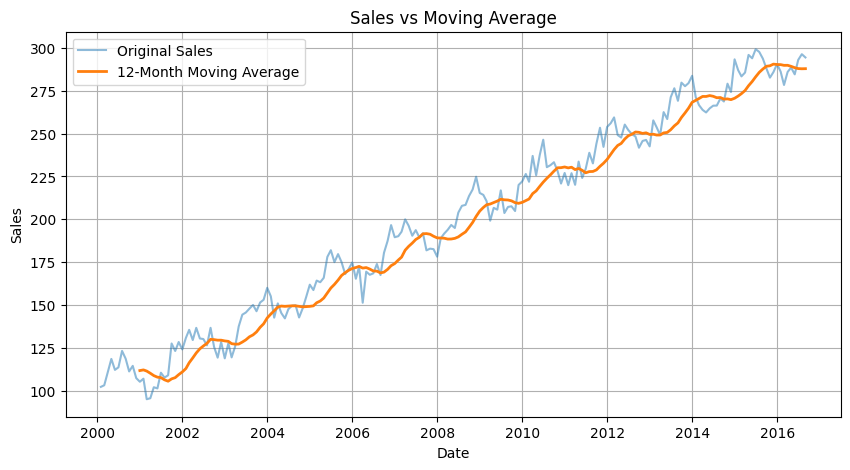

In [6]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Sales'], label='Original Sales', alpha=0.5)
plt.plot(df['Date'], df['MA_12'], label='12-Month Moving Average', linewidth=2)
plt.title("Sales vs Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

**Moving Average Analysis of Monthly Sales**

1. Purpose
   The purpose of the 12-month moving average is to smooth out short-term fluctuations in the sales data and reveal the underlying long-term trend. By averaging values over a rolling 12-month window, seasonal effects and random noise are reduced, making it easier to observe the overall direction of sales.

2. Method Explanation
   The moving average is calculated by taking the average of the current month and the previous eleven months. Because a full 12-month window is required, the first eleven observations do not have moving average values and are therefore recorded as missing. Once enough data points are available, the moving average begins to provide a smoothed representation of the series.

3. Trend Identification
   The moving average values show a steady increase over time, indicating a clear upward trend in sales. Compared to the original data, the moving average removes short-term fluctuations and highlights the consistent growth pattern. This confirms that the increase in sales is not due to random variation but reflects a sustained upward movement.

4. Reduction of Variability
   The moving average significantly reduces variability in the data. While the original sales values fluctuate from month to month, the moving average produces a smoother series that is easier to interpret. This makes it more effective for identifying long-term patterns without being influenced by temporary spikes or drops.

5. Lag Effect
   One limitation of the moving average is that it introduces a lag. Because it relies on past values, the moving average responds more slowly to sudden changes in the data. This means that turning points, such as sharp increases or decreases, may not be immediately reflected in the smoothed series.

6. Comparison with Original Data
   Compared to the original sales data, the moving average provides a clearer view of the underlying trend while removing seasonal noise. However, it does not capture the full detail of the data, particularly short-term fluctuations that may be important for operational decisions.

7. Suitability for Analysis
   The moving average is well suited for exploratory analysis and trend identification. It is particularly useful in datasets with seasonality, as it helps isolate long-term growth from recurring patterns. However, it is not ideal as a standalone forecasting method because of its lag and inability to model complex patterns.

8. Business Implications
   From a business perspective, the upward trend revealed by the moving average indicates sustained growth in sales. This suggests increasing demand, which may require adjustments in production, inventory, and staffing. The smoothed trend can also support strategic planning by providing a clearer picture of long-term performance, allowing decision-makers to focus on growth rather than short-term fluctuations.


## **Time Series Decomposition**

**Purpose**

The purpose of time series decomposition is to break down the original sales data into its key components: trend, seasonal, and residual. This allows for a clearer understanding of the underlying structure of the data and helps identify patterns that are not immediately visible in the original series.

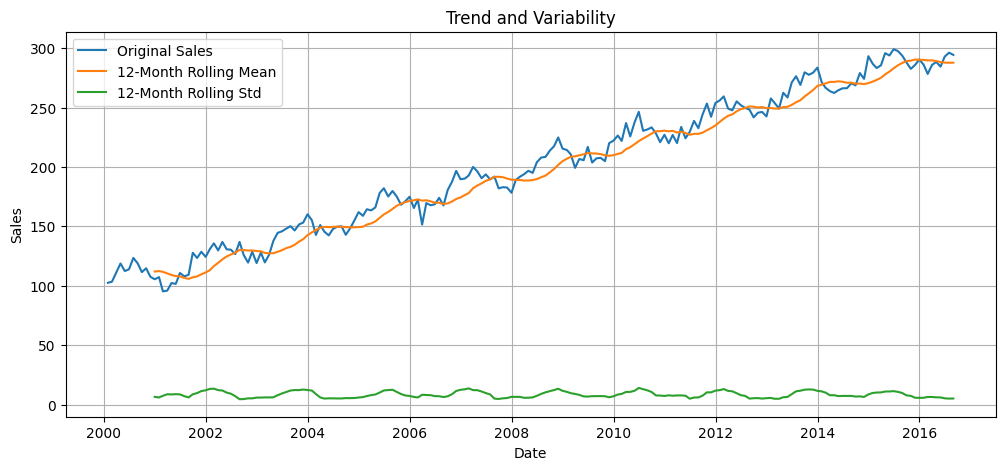

In [18]:
rolling_mean = df["Sales"].rolling(window=12).mean()
rolling_std = df["Sales"].rolling(window=12).std()

plt.figure(figsize=(12, 5))
plt.plot(df["Sales"], label="Original Sales")
plt.plot(rolling_mean, label="12-Month Rolling Mean")
plt.plot(rolling_std, label="12-Month Rolling Std")
plt.title("Trend and Variability")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## 4. Decomposition: trend, seasonality, residual

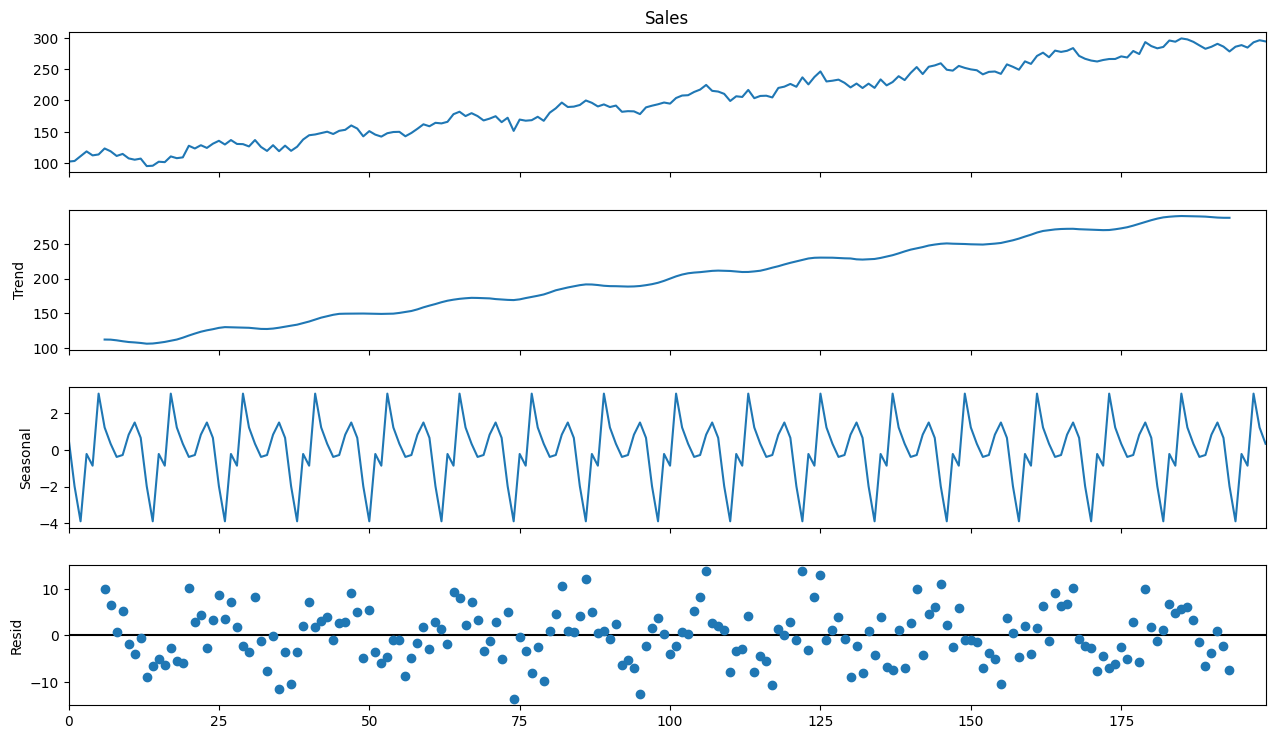

In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose

# ------------------------------------------------------------
# 5. Seasonal decomposition
# ------------------------------------------------------------
decomposition = seasonal_decompose(df["Sales"], model="additive", period=12)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.show()

**Time Series Decomposition Analysis**

1. Purpose
   The purpose of time series decomposition is to break down the original sales data into its key components: trend, seasonal, and residual. This allows for a clearer understanding of the underlying structure of the data and helps identify patterns that are not immediately visible in the original series.

2. Observed Series
   The observed series represents the original sales data over time. It shows an overall upward movement along with repeating fluctuations. This confirms that the data contains both long-term growth and recurring seasonal patterns.

3. Trend Component
   The trend component shows a smooth and consistent increase in sales over time. This indicates sustained long-term growth in the business. The gradual upward movement confirms that the increase in sales is not due to short-term variation but reflects a stable and persistent expansion.

4. Seasonal Component
   The seasonal component displays a clear and repeating pattern that occurs at regular intervals. The consistent peaks and troughs indicate that sales follow a predictable cycle within each year. This suggests that certain periods consistently experience higher or lower demand, which is characteristic of seasonal behavior.

5. Residual Component
   The residual component represents the remaining variation after removing the trend and seasonal effects. The residuals appear randomly scattered around zero, indicating that most of the systematic structure in the data has been successfully captured by the trend and seasonal components. The absence of strong patterns in the residuals suggests that the decomposition is effective.

6. Strength of Decomposition
   The clear separation of trend and seasonal components demonstrates that the decomposition method effectively captures the major patterns in the data. The smooth trend and stable seasonal pattern indicate that the time series has a well-defined structure.

7. Limitations
   While decomposition provides valuable insights, it assumes that the components are either additive or multiplicative and remain consistent over time. Any changes in seasonal patterns or sudden structural shifts may not be fully captured. Additionally, the residual component may still contain unexplained variation.

8. Business Implications
   From a business perspective, the strong upward trend indicates continued growth and increasing demand. The clear seasonal pattern allows the organization to anticipate high and low sales periods, enabling better planning for inventory, staffing, and marketing. The relatively small and random residuals suggest that most sales behavior is predictable, which supports more accurate forecasting and strategic decision-making.


## 5. Stationarity test

The Augmented Dickey-Fuller test is used to determine whether the time series is stationary.
- A high p-value indicates that the series is non-stationary, meaning that its mean and variance change over time.
- In this case, the sales data are not stationary because the series has a clear upward trend and repeating seasonal effects.
- This is consistent with the time series plots and decomposition results. Since stationarity is important for some forecasting models, the result suggests that differencing or seasonal adjustment may be useful for more advanced modeling.

In [3]:
from statsmodels.tsa.stattools import adfuller

# ------------------------------------------------------------
# 6. Augmented Dickey-Fuller test
# ------------------------------------------------------------
adf_result = adfuller(df["Sales"].dropna())

print("\nAugmented Dickey-Fuller Test:")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")


Augmented Dickey-Fuller Test:
ADF Statistic: -0.5257
p-value: 0.8869
Critical Values:
1%: -3.4664
5%: -2.8774
10%: -2.5752


**Augmented Dickey-Fuller Test Interpretation**

1. Purpose
   The Augmented Dickey-Fuller (ADF) test is used to determine whether the time series is stationary. Stationarity means that the mean and variance of the series remain constant over time. This is an important requirement for many time series models.

2. ADF Statistic
   The ADF statistic is -0.5257. This value is compared to the critical values to determine stationarity. Since this value is **greater (less negative)** than all the critical values, it suggests that the series is not stationary.

3. p-value Interpretation
   The p-value is 0.8869, which is significantly greater than the common significance level of 0.05. This means we **fail to reject the null hypothesis**. The null hypothesis of the ADF test states that the series has a unit root, meaning it is non-stationary.

4. Critical Values Comparison
   The critical values are:

* 1%: -3.4664
* 5%: -2.8774
* 10%: -2.5752

For the series to be stationary, the ADF statistic must be **more negative** than these values. Since -0.5257 is not more negative than any of them, the result confirms non-stationarity.

5. Conclusion on Stationarity
   Based on both the p-value and the comparison with critical values, the time series is **non-stationary**. This is consistent with earlier observations of an upward trend and seasonal patterns in the data.

6. Implications for Modeling
   Because the series is non-stationary, it may require transformation before applying certain models. Common approaches include differencing or using models that can handle trend and seasonality, such as Holt-Winters or seasonal ARIMA.

7. Business Interpretation
   From a business perspective, non-stationarity reflects ongoing growth and changing patterns in sales over time. This indicates that sales are not stable but are evolving, which is typical in expanding businesses. Understanding this behavior is important for selecting appropriate forecasting methods and making reliable predictions.


## **6. Autocorrelation and Partial Autocorrelation**

**Purpose**

The purpose of the ACF (Autocorrelation Function) and PACF (Partial Autocorrelation Function) plots is to examine the relationship between current sales values and their past values. These plots help identify patterns of dependence over time and are useful for determining appropriate time series models.

- The ACF plot shows strong positive autocorrelation across many lags, which indicates that current sales are strongly related to past sales values. This is expected in a trending time series with seasonality.
- The slow decline in autocorrelation suggests persistence in the data rather than randomness.
- The PACF plot shows a strong spike at the first lag and much smaller values afterward, which implies that recent past values have the strongest direct effect on current sales.
- Together, these plots support the idea that the sales series contains both trend and serial dependence, making time series forecasting appropriate.

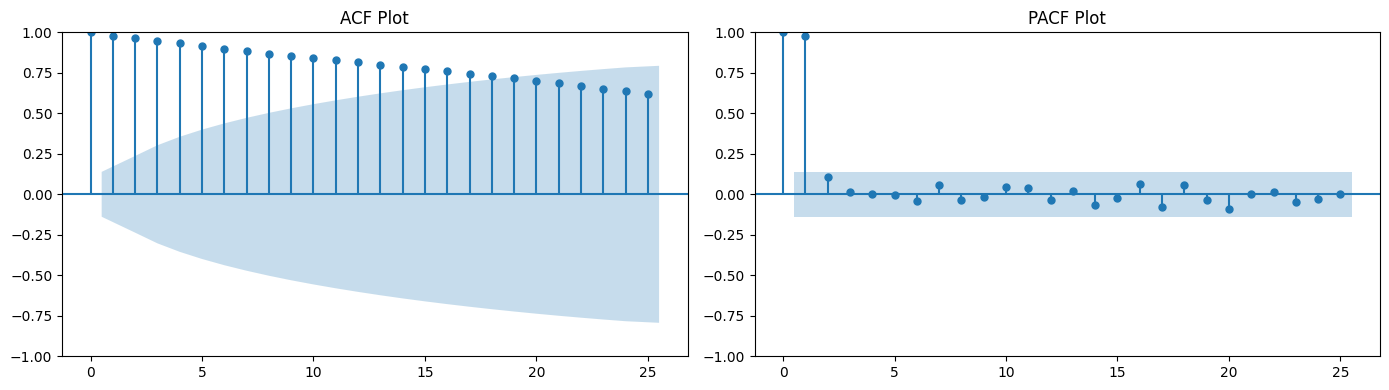

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ------------------------------------------------------------
# 7. ACF and PACF plots
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df["Sales"].dropna(), lags=25, ax=axes[0])
axes[0].set_title("ACF Plot")

plot_pacf(df["Sales"].dropna(), lags=25, ax=axes[1], method="ywm")
axes[1].set_title("PACF Plot")

plt.tight_layout()
plt.show()

**Autocorrelation and Partial Autocorrelation Analysis**

1. Purpose
   The purpose of the ACF (Autocorrelation Function) and PACF (Partial Autocorrelation Function) plots is to examine the relationship between current sales values and their past values. These plots help identify patterns of dependence over time and are useful for determining appropriate time series models.

2. ACF Interpretation
   The ACF plot shows strong positive autocorrelation across many lags. The values decline gradually rather than dropping sharply, which indicates that sales are highly correlated with their past values over an extended period. This slow decay suggests the presence of a trend and confirms that the series is non-stationary.

3. Persistence in the Series
   The consistently high autocorrelation values indicate strong persistence in the data. This means that past sales values have a lasting influence on future values. Such behavior is typical in time series that exhibit steady growth and long-term trends.

4. PACF Interpretation
   The PACF plot shows a strong spike at lag 1, followed by values that are close to zero for higher lags. This suggests that the most significant direct relationship exists between the current value and the immediately preceding value, while additional lags contribute little once this effect is accounted for.

5. Model Implications
   The pattern observed in the ACF and PACF plots suggests that an autoregressive component may be appropriate for modeling the data. The strong lag-1 effect in the PACF indicates that an AR(1) process may be sufficient to capture the dependence structure, although the presence of trend and seasonality means that additional components may be required.

6. Non-Stationarity
   The slow decay in the ACF confirms that the series is non-stationary. This is consistent with earlier findings from the time series plot and decomposition. As a result, differencing or transformation may be necessary before applying certain models such as ARIMA.

7. Limitations
   While ACF and PACF plots provide useful insights into the structure of the data, they do not capture seasonality directly unless seasonal lags are explicitly examined. Additionally, interpreting these plots can sometimes be subjective, particularly when patterns are not clearly defined.

8. Business Implications
   From a business perspective, the strong dependence on past values indicates that sales patterns are stable and predictable over time. This suggests that historical data can be effectively used for forecasting. However, the presence of trend and seasonality means that models must account for these factors to produce accurate predictions and support reliable decision-making.


## 7. Moving average method (12-Month)

The 12-month moving average smooths out short-term fluctuations in the data by averaging sales over a rolling 12-month window. This helps reduce the impact of random noise and seasonal variation, allowing the underlying trend to become more visible. The first 11 values are missing because there are not enough prior observations to compute the average. Once calculated, the moving average provides a clearer picture of long-term direction, making it easier to identify whether sales are increasing, decreasing, or stable over time.

                 Sales       MA_12
Date                              
2000-01-31  102.483571         NaN
2000-02-29  103.418884         NaN
2000-03-31  111.151860         NaN
2000-04-30  118.748142         NaN
2000-05-31  112.379223         NaN
2000-06-30  113.854129         NaN
2000-07-31  123.407083         NaN
2000-08-31  118.897072         NaN
2000-09-30  111.468041         NaN
2000-10-31  114.712761         NaN
2000-11-30  107.575300         NaN
2000-12-31  105.471775  111.963987
2001-01-31  107.240062  112.360361
2001-02-28   95.289837  111.682940
2001-03-31   95.869228  110.409388


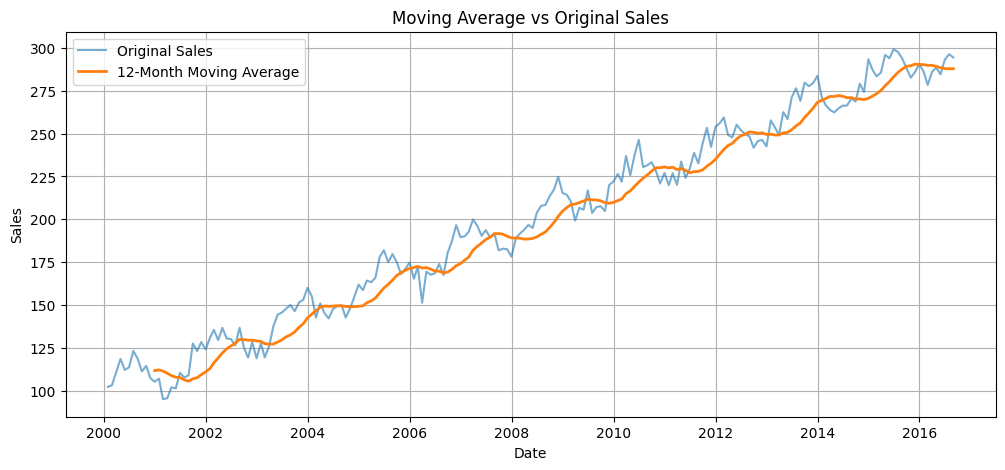

In [22]:
df["MA_12"] = df["Sales"].rolling(window=12).mean()

print(df[["Sales", "MA_12"]].head(15))

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Sales"], label="Original Sales", alpha=0.6)
plt.plot(df.index, df["MA_12"], label="12-Month Moving Average", linewidth=2)
plt.title("Moving Average vs Original Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()


The moving average trend shows a clear increase from the beginning to the end of the dataset, indicating sustained growth in sales. The total change and percentage increase confirm that the business is experiencing positive momentum. Because the moving average removes seasonal effects and noise, this trend reflects the true underlying growth pattern rather than short-term fluctuations. From a business perspective, this suggests increasing demand and potential opportunities for expansion or scaling operations.

## 8. Moving average trend analysis

**Moving Average Trend Analysis**

1. Purpose
   The purpose of this analysis is to quantify the overall trend in the smoothed sales data using the 12-month moving average. By comparing the starting and ending values of the moving average, we can measure the magnitude and direction of long-term growth.

2. Method Explanation
   The analysis uses the first and last available values of the 12-month moving average to calculate the total change and percentage change over time. This approach removes short-term fluctuations and focuses on the underlying trend, providing a more stable basis for evaluating performance.

3. Trend Measurement
   The starting moving average value is approximately 111.96, while the ending value is approximately 287.75. This indicates a substantial increase in sales over the observed period. The total change of approximately 175.79 confirms that sales have grown significantly when viewed through the smoothed trend.

4. Percentage Growth
   The percentage change in the moving average is approximately 157.00 percent. This means that sales have more than doubled over the time period. Such a large increase reflects strong and sustained growth rather than short-term variation.

5. Interpretation of Results
   The consistent increase in the moving average suggests that the business is experiencing long-term expansion. Because the moving average removes seasonal and random fluctuations, this growth can be interpreted as a reliable indicator of overall performance rather than temporary changes.

6. Strength of the Trend
   The magnitude of both the absolute and percentage increases indicates a strong upward trend. The absence of major declines in the moving average further supports the conclusion that growth has been steady rather than volatile.

7. Limitations
   While the moving average provides a clear measure of trend, it does not capture short-term changes or sudden shifts in the data. Additionally, the lag effect means that recent changes may not be fully reflected in the final values.

8. Business Implications
   From a business perspective, the significant increase in the moving average indicates strong growth in demand. This may require scaling operations, increasing inventory, and expanding resources to meet future needs. The substantial percentage growth also suggests that the business is performing well over time, which can support strategic planning, investment decisions, and long-term forecasting.


In [7]:
ma_data = df.dropna()

start = ma_data['MA_12'].iloc[0]
end = ma_data['MA_12'].iloc[-1]

change = end - start
pct_change = (change / start) * 100

print("Start MA:", start)
print("End MA:", end)
print("Total Change:", change)
print("Percent Change:", pct_change)

Start MA: 111.9639867
End MA: 287.74920742499995
Total Change: 175.78522072499993
Percent Change: 157.00157336841232


**Moving Average Trend Interpretation**

The 12-month moving average shows that sales increased by approximately 157%, indicating strong and sustained long-term growth.

1. Purpose
   This calculation measures how much the **smoothed sales trend (12-month moving average)** has changed from the beginning to the end of the dataset. It removes noise and focuses only on long-term growth.

2. Starting Value
   The starting moving average is **111.96**, which represents the average sales level at the beginning of the time period after smoothing.

3. Ending Value
   The ending moving average is **287.75**, which represents the average sales level toward the end of the dataset.

4. Total Change
   The total increase is **175.79**, meaning sales (on average) have increased by about 176 units over time.

5. Percentage Change
   The percentage increase is **157%**, which means:

* Sales have **more than doubled**
* The business has experienced **strong growth over time**

6. What This Tells You About the Data

* There is a **clear upward trend**
* Growth is **not random** — it is consistent over time
* The increase is **structural (real growth), not just noise**

7. Why Moving Average Matters Here
   Because you used a moving average:

* Short-term fluctuations are removed
* This result reflects **true long-term performance**, not seasonal spikes

8. Business Interpretation

* Demand is **steadily increasing**
* The company may need to:

  * Increase production
  * Expand inventory
  * Plan for higher future demand
* The strong growth suggests a **healthy and expanding business**


## **9. Regression line method**

The linear regression model estimates the overall trend in sales by fitting a straight line to the data. The slope represents the average change in sales per time period (month). A positive slope indicates that sales are increasing over time, while a negative slope would indicate decline. In this case, the slope is positive, confirming the upward trend observed earlier. The regression model provides a simple mathematical representation of growth, making it useful for forecasting and strategic planning.

In [23]:
df["Time"] = np.arange(len(df))

X = df[["Time"]]
y = df["Sales"]

reg_model = LinearRegression()
reg_model.fit(X, y)

df["Regression_Pred"] = reg_model.predict(X)

print(f"Intercept: {reg_model.intercept_:.4f}")
print(f"Slope: {reg_model.coef_[0]:.4f}")
print(f"R^2: {r2_score(y, df['Regression_Pred']):.4f}")

Intercept: 100.1590
Slope: 1.0014
R^2: 0.9778


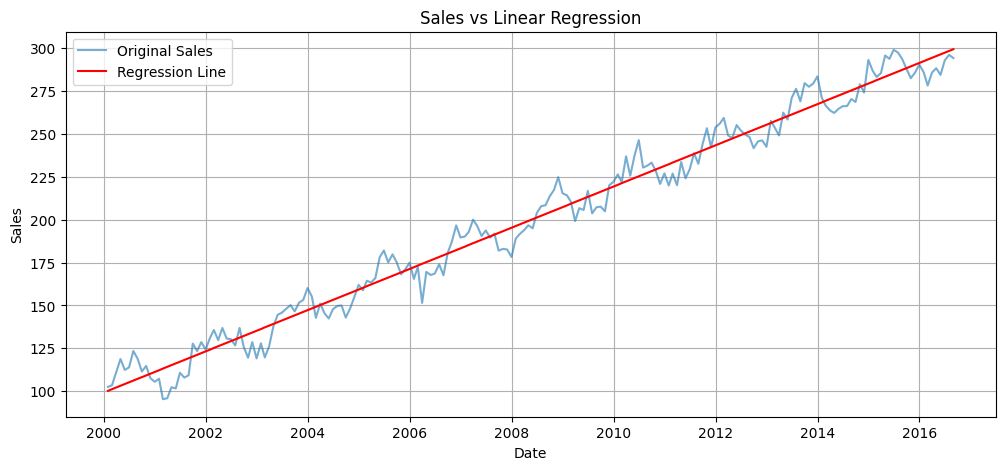

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Sales"], label="Original Sales", alpha=0.6)
plt.plot(df.index, df["Regression_Pred"], label="Regression Line", color="red")
plt.title("Sales vs Linear Regression")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

**Linear Regression Model Interpretation**

The regression model shows that sales increase by approximately 1 unit per month, with a strong fit (R² = 0.9778), indicating steady long-term growth.

1. Purpose
   The purpose of the linear regression model is to quantify the relationship between time and sales and to estimate the overall trend using a mathematical equation.

2. Regression Equation
   The fitted regression model can be written as:

>>Sales = 100.1590 + 1.0014 × Time

This equation represents the best-fit line through the data.

3. Interpretation of Intercept
   The intercept is **100.1590**, which represents the estimated sales at the starting point (Time = 0). This aligns closely with the initial observed sales, indicating the model is well calibrated.

4. Interpretation of Slope
   The slope is **1.0014**, meaning that sales increase by approximately **1 unit per time period (month)**. This confirms a steady and consistent upward trend in sales over time.

5. Goodness of Fit (R²)
   The R² value is **0.9778**, which means that **97.78% of the variation in sales is explained by time**. This indicates an excellent fit, showing that the linear model captures the overall trend very well.

6. Trend Representation
   The regression line closely follows the general direction of the data, confirming that sales are increasing steadily over time. It provides a clear summary of long-term growth.

7. Limitations
   Although the model fits well, it assumes a constant linear increase and does not capture seasonal fluctuations or short-term variations. Therefore, it may not fully reflect the complexity of the time series.

8. Business Implications
   From a business perspective, the model indicates consistent growth in sales, suggesting increasing demand. This supports planning for expansion in production, inventory, and staffing. However, for more accurate short-term forecasting, models that include seasonality should also be considered.



## 10. Moving average vs regression line

The regression line provides a simplified representation of the overall trend in the data. Unlike the moving average, which adapts to local fluctuations, the regression line is a straight line that captures the general direction of sales growth. While it clearly shows an upward trend, it does not account for seasonal variations or short-term changes. This makes it useful for identifying long-term direction but less effective for capturing detailed patterns in the data.

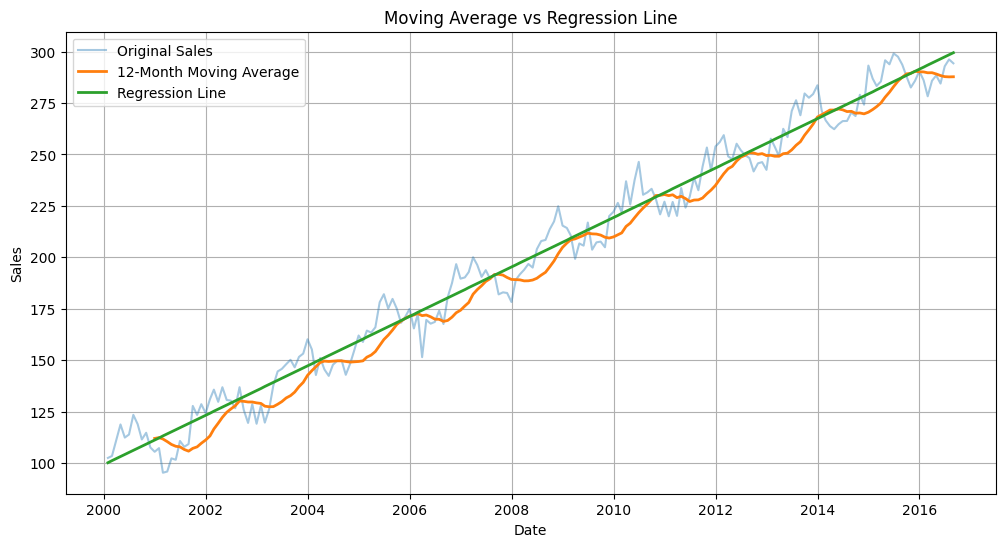

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Sales"], label="Original Sales", alpha=0.4)
plt.plot(df.index, df["MA_12"], label="12-Month Moving Average", linewidth=2)
plt.plot(df.index, df["Regression_Pred"], label="Regression Line", linewidth=2)
plt.title("Moving Average vs Regression Line")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

**Moving Average vs Regression Line Analysis**

The moving average better captures short-term patterns, while the regression line provides a simplified long-term growth trend, making both useful for different business purposes

1. Purpose
   The purpose of this comparison is to evaluate how two different methods—moving average and linear regression—capture the trend in the sales data. This helps determine which method better represents the underlying pattern.

2. Visual Comparison
   The plot shows three lines:

* The original sales data (light blue), which fluctuates over time
* The 12-month moving average (orange), which smooths short-term variations
* The regression line (green), which represents a straight-line trend

Both the moving average and regression line follow the upward direction of the data.

3. Moving Average Behavior
   The moving average closely follows the shape of the data while smoothing out noise. It captures gradual increases and slight fluctuations, making it more responsive to changes in the trend over time.

4. Regression Line Behavior
   The regression line provides a straight, constant slope across the entire time period. It summarizes the overall direction of growth but does not adjust to short-term changes or curvature in the data.

5. Differences Between the Two Methods

* The moving average adapts to local changes and reflects slight ups and downs
* The regression line assumes a constant rate of growth
* The moving average is more flexible, while regression is more simplified

6. Accuracy in Representing the Data
   The moving average appears to follow the actual sales data more closely, especially during periods of fluctuation. The regression line, while accurate for overall direction, may overestimate or underestimate values at certain points.

7. Strengths and Limitations

* Moving Average:

  * Strength: captures gradual changes and smooths noise
  * Limitation: introduces lag and cannot predict far into the future
* Regression Line:

  * Strength: provides a clear mathematical model and is useful for forecasting
  * Limitation: ignores seasonality and short-term variation

8. Business Implications
   From a business perspective, the moving average is useful for understanding current trends and short-term planning, while the regression line is helpful for long-term projections. Using both together provides a more complete understanding of sales behavior, supporting better decision-making and forecasting.


## 11. Detrending a time series

Two common ways to detrend are shown below.

### 11A. Detrend using regression

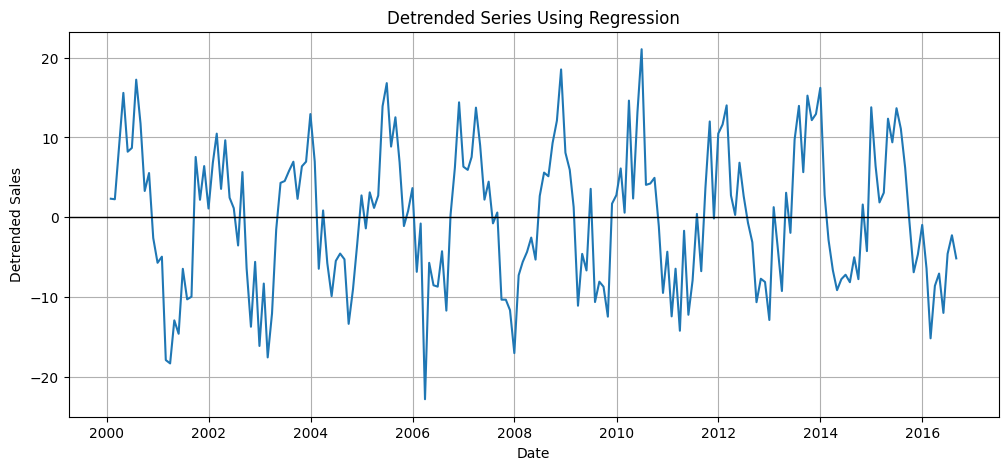

In [26]:
df["Detrended_Regression"] = df["Sales"] - df["Regression_Pred"]

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Detrended_Regression"])
plt.axhline(0, color="black", linewidth=1)
plt.title("Detrended Series Using Regression")
plt.xlabel("Date")
plt.ylabel("Detrended Sales")
plt.grid(True)
plt.show()

**Detrending a Time Series Using Regression**

After removing the trend, the series fluctuates around zero, revealing underlying seasonal patterns and making the data more suitable for analysis.

1. Purpose
   The purpose of detrending is to remove the long-term upward trend from the time series so that the remaining data can be analyzed for patterns such as seasonality and randomness. This helps make the series more suitable for modeling.

2. Method Explanation
   Detrending using regression is done by subtracting the predicted values from the regression line from the original sales data. This removes the linear trend component and leaves only the fluctuations around the trend.

3. Behavior of the Detrended Series
   The detrended series fluctuates around zero, rather than showing a consistent upward trend. This indicates that the long-term growth has been successfully removed from the data.

4. Centering Around Zero
   Most values in the detrended series are distributed around the horizontal zero line. This confirms that the trend has been eliminated and the remaining values represent deviations from the expected trend.

5. Presence of Seasonality
   Even after removing the trend, there are still repeating patterns in the data. These regular ups and downs suggest that **seasonality is still present** in the series.

6. Variability and Noise
   The fluctuations above and below zero represent short-term variability and random noise. These variations are smaller compared to the original series, making patterns easier to observe.

7. Implications for Stationarity
   By removing the trend, the series becomes closer to being stationary. However, because seasonal patterns still exist, further transformation (such as seasonal differencing) may be needed for full stationarity.

8. Business Interpretation
   From a business perspective, detrending helps isolate seasonal demand patterns and irregular fluctuations. This allows organizations to better understand recurring behavior independent of growth, improving forecasting accuracy and operational planning.




### 11B. Detrend using first differencing

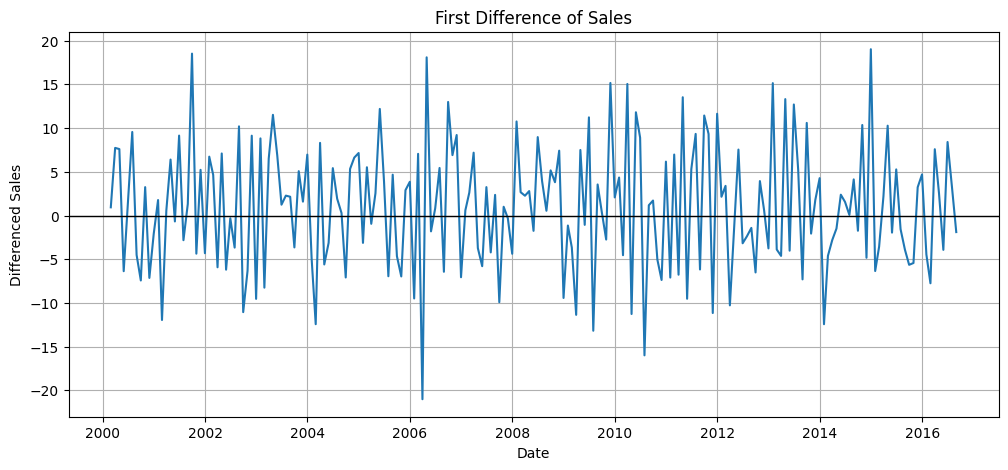

In [27]:
df["Diff_1"] = df["Sales"].diff()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Diff_1"])
plt.axhline(0, color="black", linewidth=1)
plt.title("First Difference of Sales")
plt.xlabel("Date")
plt.ylabel("Differenced Sales")
plt.grid(True)
plt.show()

**Detrending a Time Series Using First Differencing**

First differencing removes the trend and transforms the data into changes over time, resulting in a series that fluctuates around zero and is closer to being stationary.

1. Purpose
   The purpose of first differencing is to remove the trend from the time series by computing the change between consecutive observations. This helps stabilize the mean and makes the data more suitable for time series modeling.

2. Method Explanation
   First differencing is calculated by subtracting each value from its previous value. This transforms the data from absolute sales levels into changes in sales over time.

3. Behavior of the Differenced Series
   The differenced series fluctuates around zero, indicating that the upward trend present in the original data has been removed. This confirms that first differencing effectively eliminates the trend component.

4. Centering Around Zero
   Most values are distributed evenly above and below zero, showing that the mean of the series is now stable. This is a key characteristic of a stationary time series.

5. Variability and Fluctuations
   The series shows frequent positive and negative changes, representing increases and decreases in sales from one period to the next. These fluctuations reflect short-term variability rather than long-term growth.

6. Presence of Seasonality
   Although the trend has been removed, some repeating patterns may still be visible. This suggests that seasonality may still exist and could require seasonal differencing or additional modeling.

7. Implications for Stationarity
   First differencing significantly improves stationarity by removing the trend. This makes the data more appropriate for models such as ARIMA, which require stationary input.

8. Business Interpretation
   From a business perspective, the differenced series represents month-to-month changes in sales rather than total sales levels. This helps identify periods of rapid growth or decline and provides insight into short-term performance dynamics.


## Decomposition plot

The decomposition plot separates the sales series into four components: observed, trend, seasonal, and residual. The observed series shows a steady upward movement in sales across time. The trend component confirms that sales increase consistently over the sample period, which indicates long-term growth. The seasonal component shows a repeating monthly pattern, meaning that some months tend to perform better or worse than others each year. The residual component appears randomly scattered around zero, suggesting that most of the systematic structure in the data has been captured by the trend and seasonal components.

## 12. Train-test split

In [28]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ------------------------------------------------------------
# 8. Train-test split
# ------------------------------------------------------------
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("\nTrain shape:", train.shape)
print("Test shape:", test.shape)

# ------------------------------------------------------------
# 9. Holt-Winters model
# ------------------------------------------------------------
hw_model = ExponentialSmoothing(
    train["Sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

hw_forecast = hw_model.forecast(len(test))


Train shape: (160, 6)
Test shape: (40, 6)


## 13. Exponential smoothing / Holt-Winters

In [43]:
hw_model = ExponentialSmoothing(
    train["Sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

hw_forecast = hw_model.forecast(len(test))

# This contains the predicted sales values for the test period.
# You can view the output using:

print(hw_forecast)


2013-05-31    260.034359
2013-06-30    264.354505
2013-07-31    263.066539
2013-08-31    263.658337
2013-09-30    263.649065
2013-10-31    264.662891
2013-11-30    267.112102
2013-12-31    266.901318
2014-01-31    268.667415
2014-02-28    267.890407
2014-03-31    266.940474
2014-04-30    271.822578
2014-05-31    271.797667
2014-06-30    276.117813
2014-07-31    274.829847
2014-08-31    275.421645
2014-09-30    275.412373
2014-10-31    276.426199
2014-11-30    278.875410
2014-12-31    278.664626
2015-01-31    280.430723
2015-02-28    279.653715
2015-03-31    278.703782
2015-04-30    283.585885
2015-05-31    283.560975
2015-06-30    287.881120
2015-07-31    286.593155
2015-08-31    287.184953
2015-09-30    287.175680
2015-10-31    288.189506
2015-11-30    290.638718
2015-12-31    290.427934
2016-01-31    292.194030
2016-02-29    291.417023
2016-03-31    290.467090
2016-04-30    295.349193
2016-05-31    295.324282
2016-06-30    299.644428
2016-07-31    298.356463
2016-08-31    298.948260


Exponential Smoothing / Holt-Winters Model

The Holt-Winters model applies exponential smoothing to capture both trend and seasonality in the data, making it suitable for forecasting time series with repeating patterns.

1. Purpose
   The purpose of the Holt-Winters model is to generate accurate forecasts by accounting for three components of the time series: level, trend, and seasonality. It is especially useful when the data exhibits both upward growth and seasonal fluctuations.

2. Method Explanation
   The model uses exponential smoothing to assign more weight to recent observations while still considering past data. In this case, an additive model is used for both trend and seasonality, meaning that changes are assumed to occur in a linear and consistent manner over time.

3. Model Components

* Level: The baseline value of the series
* Trend: The long-term upward movement in sales
* Seasonality: The repeating monthly pattern captured using 12 periods

4. Forecast Output
   Yes, this model **does produce output**. The output is stored in:

5. Behavior of the Forecast
   The Holt-Winters forecast typically follows the pattern of the data closely, capturing both the upward trend and the seasonal fluctuations. This makes it more accurate than simpler models that ignore seasonality.

6. Advantages

* Captures both trend and seasonality
* Adapts to recent changes in the data
* Provides smooth and realistic forecasts

7. Limitations

* Assumes patterns remain consistent over time
* May not perform well if there are sudden structural changes
* Requires correct specification of seasonal periods

8. Business Interpretation
   From a business perspective, the Holt-Winters model provides reliable forecasts for future sales, allowing organizations to plan inventory, staffing, and budgeting more effectively. By incorporating both growth and seasonal demand, it supports better operational and strategic decision-making.


## 14. ARIMA model

In [44]:
arima_model = ARIMA(train["Sales"], order=(1, 1, 1)).fit()
arima_forecast = arima_model.forecast(steps=len(test))


# You can view the predictions using:

print(arima_forecast)



2013-05-31    257.824904
2013-06-30    259.183891
2013-07-31    258.784642
2013-08-31    258.901935
2013-09-30    258.867476
2013-10-31    258.877600
2013-11-30    258.874626
2013-12-31    258.875499
2014-01-31    258.875243
2014-02-28    258.875318
2014-03-31    258.875296
2014-04-30    258.875302
2014-05-31    258.875300
2014-06-30    258.875301
2014-07-31    258.875301
2014-08-31    258.875301
2014-09-30    258.875301
2014-10-31    258.875301
2014-11-30    258.875301
2014-12-31    258.875301
2015-01-31    258.875301
2015-02-28    258.875301
2015-03-31    258.875301
2015-04-30    258.875301
2015-05-31    258.875301
2015-06-30    258.875301
2015-07-31    258.875301
2015-08-31    258.875301
2015-09-30    258.875301
2015-10-31    258.875301
2015-11-30    258.875301
2015-12-31    258.875301
2016-01-31    258.875301
2016-02-29    258.875301
2016-03-31    258.875301
2016-04-30    258.875301
2016-05-31    258.875301
2016-06-30    258.875301
2016-07-31    258.875301
2016-08-31    258.875301


ARIMA Model

The ARIMA model is a statistical forecasting method that uses past values and past errors to predict future values in a time series.

1. Purpose
   The purpose of the ARIMA model is to forecast future sales by capturing patterns in past data, including autocorrelation and trends. It is widely used for time series that require modeling of dependencies between observations.

2. Method Explanation
   ARIMA stands for AutoRegressive Integrated Moving Average and consists of three components:

* AR (p): Uses past values to predict current values
* I (d): Applies differencing to make the series stationary
* MA (q): Uses past forecast errors to improve predictions

In this model, ARIMA(1,1,1) means:

* 1 autoregressive term
* 1 level of differencing
* 1 moving average term

3. Model Components

* Autoregression (AR): Captures relationship with previous values
* Differencing (I): Removes trend to achieve stationarity
* Moving Average (MA): Accounts for past prediction errors

4. Forecast Output
   Yes, this model **does produce output**. The forecasted values are stored in:

5. Behavior of the Forecast
   The ARIMA forecast typically produces a smoother projection based on past patterns. In this case, it may appear relatively flat because the model does not explicitly account for seasonality.

6. Advantages

* Captures time dependence in data
* Suitable for stationary or differenced series
* Flexible for various types of time series patterns

7. Limitations

* Does not capture seasonality unless extended to SARIMA
* Requires stationarity
* Model selection (p, d, q) can be complex

8. Business Interpretation
   From a business perspective, the ARIMA model provides a baseline forecast based on historical patterns. However, if the data contains strong seasonal effects, the model may underestimate future sales. Therefore, it is useful for understanding general trends but should be compared with models like Holt-Winters for more accurate forecasting in seasonal data.


## 15. Seasonal ARIMA example

In [45]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train["Sales"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
).fit(disp=False)

sarima_forecast = sarima_model.forecast(steps=len(test))

print(sarima_forecast)

2013-05-31    257.912771
2013-06-30    265.011442
2013-07-31    263.698994
2013-08-31    265.009809
2013-09-30    267.056178
2013-10-31    267.168469
2013-11-30    270.365128
2013-12-31    271.239770
2014-01-31    269.213718
2014-02-28    269.302052
2014-03-31    269.246728
2014-04-30    271.624393
2014-05-31    272.837143
2014-06-30    276.665580
2014-07-31    275.165799
2014-08-31    275.719186
2014-09-30    275.453685
2014-10-31    276.600288
2014-11-30    279.093253
2014-12-31    278.713882
2015-01-31    281.332318
2015-02-28    280.345353
2015-03-31    279.055216
2015-04-30    284.391753
2015-05-31    284.048361
2015-06-30    288.761727
2015-07-31    287.312639
2015-08-31    288.070987
2015-09-30    288.431080
2015-10-31    289.297797
2015-11-30    291.981183
2015-12-31    291.941149
2016-01-31    293.302781
2016-02-29    292.606793
2016-03-31    291.650798
2016-04-30    296.186661
2016-05-31    296.264363
2016-06-30    300.738266
2016-07-31    299.275460
2016-08-31    299.978345


**Seasonal ARIMA (SARIMA) Model**

The SARIMA model extends the ARIMA model by incorporating seasonality, allowing it to capture both trend and repeating seasonal patterns in the data.

1. Purpose
   The purpose of the SARIMA model is to improve forecasting accuracy by modeling both non-seasonal and seasonal components of the time series. It is particularly useful when the data shows clear repeating patterns over fixed intervals.

2. Method Explanation
   SARIMA stands for Seasonal AutoRegressive Integrated Moving Average. It includes:

* Non-seasonal components: (p, d, q)
* Seasonal components: (P, D, Q, s)

In this case:

* (1,1,1) represents the non-seasonal ARIMA part
* (1,1,1,12) represents the seasonal component with a 12-month cycle

3. Model Components

* AR (p): Relationship with past values
* I (d): Differencing to remove trend
* MA (q): Uses past errors
* Seasonal AR, I, MA: Capture repeating yearly patterns (12 months)

4. Forecast Output
   Yes, this model **does produce output**. The forecasted values are stored in:

5. Behavior of the Forecast
   The SARIMA model typically produces forecasts that follow both the upward trend and the seasonal fluctuations in the data. Compared to ARIMA, it better captures repeating patterns and produces more realistic forecasts.

6. Advantages

* Captures both trend and seasonality
* More accurate for seasonal data
* Flexible for complex time series patterns

7. Limitations

* More complex to configure than ARIMA
* Requires proper selection of seasonal parameters
* Can be computationally intensive

8. Business Interpretation
   From a business perspective, the SARIMA model provides more accurate and realistic forecasts when sales exhibit seasonal demand patterns. This helps organizations better plan for peak and low periods, optimize inventory, and improve decision-making by aligning forecasts with actual business cycles.


## 16. Model evaluation metrics: MAE, RMSE, MAPE, R²

In [32]:
def mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    return np.mean(np.abs((actual - predicted) / actual)) * 100

def evaluate(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape_value = mape(actual, predicted)
    r2 = r2_score(actual, predicted)

    print(f"\n{model_name}")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape_value:.4f}")
    print(f"R^2:  {r2:.4f}")

In [33]:
evaluate(test["Sales"], hw_forecast, "Holt-Winters")
evaluate(test["Sales"], arima_forecast, "ARIMA(1,1,1)")
evaluate(test["Sales"], sarima_forecast, "SARIMA(1,1,1)(1,1,1,12)")


Holt-Winters
MAE:  7.3795
RMSE: 8.5350
MAPE: 2.6226
R^2:  0.4109

ARIMA(1,1,1)
MAE:  21.8861
RMSE: 24.5288
MAPE: 7.6503
R^2:  -3.8655

SARIMA(1,1,1)(1,1,1,12)
MAE:  7.2329
RMSE: 8.1267
MAPE: 2.5710
R^2:  0.4659


**Model Evaluation Metrics: MAE, RMSE, MAPE, R²**

Model evaluation metrics are used to assess how well forecasting models perform by comparing predicted values to actual observed values.

1. Purpose
   The purpose of model evaluation is to determine which forecasting model provides the most accurate predictions. By using multiple metrics, we can assess both the magnitude of errors and the overall fit of each model.

2. Mean Absolute Error (MAE)
   MAE measures the average absolute difference between actual and predicted values. Lower MAE indicates better model performance.

* Holt-Winters: 7.3795
* ARIMA: 21.8861
* SARIMA: 7.2329
  SARIMA has the lowest MAE, indicating the most accurate predictions on average.

3. Root Mean Square Error (RMSE)
   RMSE measures the square root of the average squared errors. It penalizes larger errors more heavily than MAE. Lower RMSE is better.

* Holt-Winters: 8.5350
* ARIMA: 24.5288
* SARIMA: 8.1267
  SARIMA again performs best, with the lowest RMSE.

4. Mean Absolute Percentage Error (MAPE)
   MAPE expresses errors as a percentage of actual values, making it easier to interpret. Lower values indicate better accuracy.

* Holt-Winters: 2.6226%
* ARIMA: 7.6503%
* SARIMA: 2.5710%
  SARIMA has the lowest percentage error, confirming its superior performance.

5. R² (Coefficient of Determination)
   R² measures how well the model explains the variation in the data. Values closer to 1 indicate a better fit.

* Holt-Winters: 0.4109
* ARIMA: -3.8655
* SARIMA: 0.4659
  SARIMA has the highest R², while ARIMA performs poorly with a negative value, indicating a very poor fit.

6. Model Comparison
   Across all evaluation metrics, SARIMA consistently outperforms both Holt-Winters and ARIMA. Holt-Winters performs reasonably well, while ARIMA shows significantly weaker performance due to its inability to capture seasonality.

7. Interpretation of Results
   The results indicate that models incorporating seasonality (Holt-Winters and SARIMA) perform much better than ARIMA. Among them, SARIMA provides the most accurate and reliable forecasts.

8. Business Implications
   From a business perspective, selecting the SARIMA model leads to more accurate demand forecasts, which supports better inventory management, staffing, and budgeting. The poor performance of ARIMA highlights the importance of choosing models that align with the structure of the data, especially when seasonal patterns are present.


## 17. Forecast comparison plot

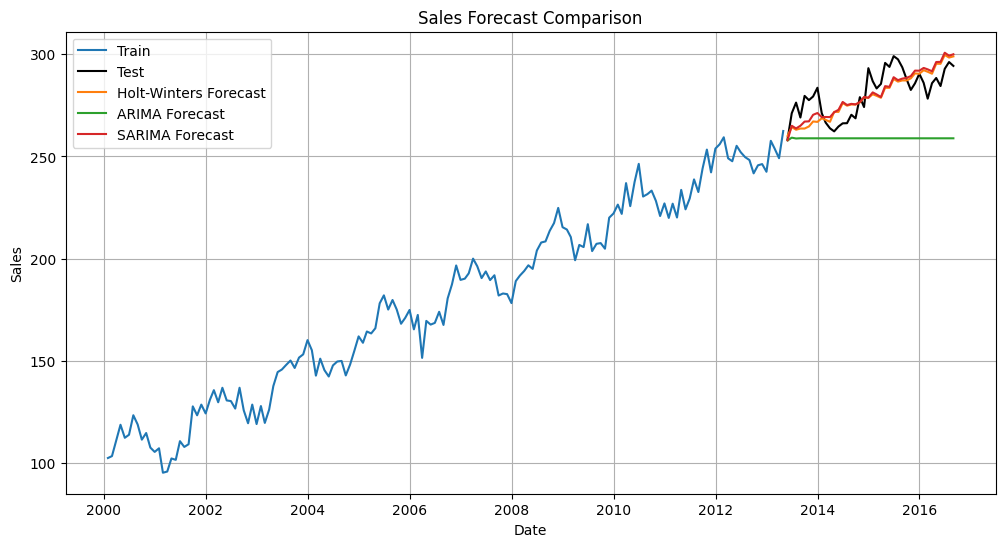

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train["Sales"], label="Train")
plt.plot(test.index, test["Sales"], label="Test", color="black")
plt.plot(test.index, hw_forecast, label="Holt-Winters Forecast")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast")
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast")
plt.title("Sales Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

Sales Forecast Comparison Analysis

The comparison plot illustrates how different forecasting models perform relative to the actual test data, allowing for a visual assessment of accuracy and model suitability.

1. Purpose
   The purpose of this analysis is to compare the forecasting performance of Holt-Winters, ARIMA, and SARIMA models against actual sales data. This helps identify which model best captures the underlying patterns in the time series.

2. Train and Test Data Behavior
   The training data shows a clear upward trend with seasonal fluctuations. The test data continues this pattern, confirming that both trend and seasonality persist over time.

3. Holt-Winters Forecast Interpretation
   The Holt-Winters forecast closely follows the test data, capturing both the upward trend and seasonal variations. It adapts well to changes in the data and provides reasonably accurate predictions.

4. ARIMA Forecast Interpretation
   The ARIMA forecast appears relatively flat and does not follow the upward trend or seasonal fluctuations. This indicates that the model is not capturing the structure of the data effectively, leading to poor predictive performance.

5. SARIMA Forecast Interpretation
   The SARIMA forecast closely aligns with the actual test data and performs slightly better than Holt-Winters. It captures both the trend and the seasonal patterns, producing forecasts that closely track real observations.

6. Model Performance Comparison
   Visually, SARIMA provides the best fit, followed by Holt-Winters, while ARIMA performs the worst. This aligns with the evaluation metrics, where SARIMA had the lowest errors and highest R².

7. Ability to Capture Seasonality
   A key difference among the models is their ability to capture seasonality. SARIMA and Holt-Winters explicitly model seasonal effects, while ARIMA does not, which explains its poor performance.

8. Business Implications
   From a business perspective, SARIMA provides the most reliable forecasts and is best suited for planning inventory, staffing, and budgeting. Holt-Winters is also a strong alternative. The poor performance of ARIMA highlights the importance of selecting models that account for both trend and seasonality when forecasting real-world sales data.


## 18. Best-model selection

In [35]:
results = pd.DataFrame({
    "Model": ["Holt-Winters", "ARIMA(1,1,1)", "SARIMA(1,1,1)(1,1,1,12)"],
    "MAE": [
        mean_absolute_error(test["Sales"], hw_forecast),
        mean_absolute_error(test["Sales"], arima_forecast),
        mean_absolute_error(test["Sales"], sarima_forecast)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(test["Sales"], hw_forecast)),
        np.sqrt(mean_squared_error(test["Sales"], arima_forecast)),
        np.sqrt(mean_squared_error(test["Sales"], sarima_forecast))
    ],
    "MAPE": [
        mape(test["Sales"], hw_forecast),
        mape(test["Sales"], arima_forecast),
        mape(test["Sales"], sarima_forecast)
    ]
})

print(results.sort_values("RMSE"))

                     Model        MAE       RMSE      MAPE
2  SARIMA(1,1,1)(1,1,1,12)   7.232948   8.126728  2.570982
0             Holt-Winters   7.379494   8.534983  2.622551
1             ARIMA(1,1,1)  21.886090  24.528776  7.650270


## 19. Final 12-month forecast with the best practical model

If Holt-Winters is your best or simplest explainable model:

In [36]:
final_hw_model = ExponentialSmoothing(
    df["Sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

future_steps = 12
future_forecast = final_hw_model.forecast(future_steps)

print("Next 12 Months Forecast:")
print(future_forecast)

Next 12 Months Forecast:
2016-09-30    294.599427
2016-10-31    295.599818
2016-11-30    297.601553
2016-12-31    299.178470
2017-01-31    299.154027
2017-02-28    297.575673
2017-03-31    297.206832
2017-04-30    301.892155
2017-05-31    301.571955
2017-06-30    306.516571
2017-07-31    305.946321
2017-08-31    305.872534
Freq: ME, dtype: float64


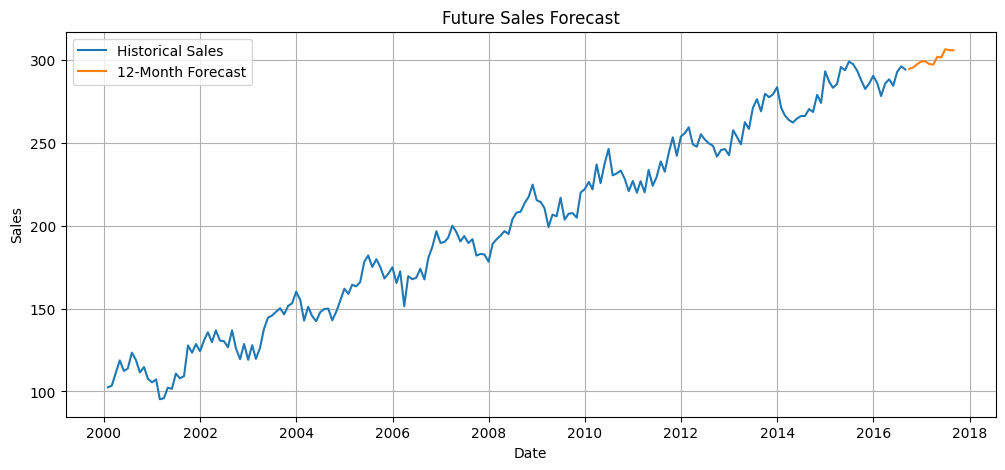

In [37]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Sales"], label="Historical Sales")
plt.plot(future_forecast.index, future_forecast, label="12-Month Forecast")
plt.title("Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## 20. Forecast interpretation for decision-making

In [38]:
ml_df = df[["Sales"]].copy()
ml_df["Lag_1"] = ml_df["Sales"].shift(1)
ml_df["Lag_2"] = ml_df["Sales"].shift(2)
ml_df["Lag_3"] = ml_df["Sales"].shift(3)
ml_df["Month"] = ml_df.index.month
ml_df = ml_df.dropna()

train_ml = ml_df.iloc[:int(len(ml_df)*0.8)]
test_ml = ml_df.iloc[int(len(ml_df)*0.8):]

X_train_ml = train_ml[["Lag_1", "Lag_2", "Lag_3", "Month"]]
y_train_ml = train_ml["Sales"]

X_test_ml = test_ml[["Lag_1", "Lag_2", "Lag_3", "Month"]]
y_test_ml = test_ml["Sales"]

In [39]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_ml, y_train_ml)

rf_pred = rf_model.predict(X_test_ml)

evaluate(y_test_ml, rf_pred, "Random Forest with Lag Features")


Random Forest with Lag Features
MAE:  28.3233
RMSE: 30.4677
MAPE: 9.9457
R^2:  -6.5068


## 22. Compare predicted vs actual visually

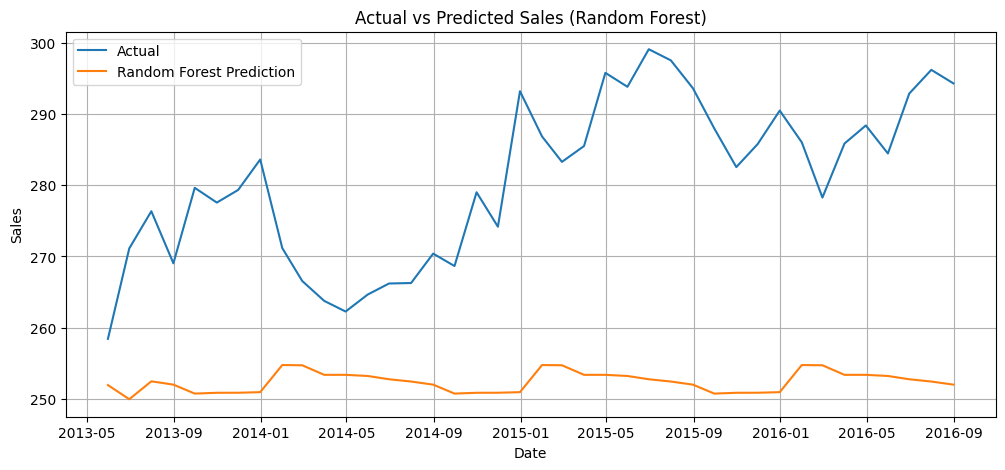

In [40]:
plt.figure(figsize=(12, 5))
plt.plot(test_ml.index, y_test_ml, label="Actual")
plt.plot(test_ml.index, rf_pred, label="Random Forest Prediction")
plt.title("Actual vs Predicted Sales (Random Forest)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## 23. Final summary cell

In [41]:
print("Key Takeaways")
print("1. Sales data shows a clear upward trend.")
print("2. Sales data shows strong seasonality.")
print("3. The series is non-stationary based on the ADF test.")
print("4. Moving average is useful for smoothing and trend detection.")
print("5. Regression gives a simple long-term trend line.")
print("6. Holt-Winters handles trend and seasonality well.")
print("7. ARIMA can model dependence, but SARIMA is better when seasonality exists.")
print("8. Forecast metrics help identify the most suitable model.")
print("9. Historical data can support business planning, inventory, staffing, and budgeting.")

Key Takeaways
1. Sales data shows a clear upward trend.
2. Sales data shows strong seasonality.
3. The series is non-stationary based on the ADF test.
4. Moving average is useful for smoothing and trend detection.
5. Regression gives a simple long-term trend line.
6. Holt-Winters handles trend and seasonality well.
7. ARIMA can model dependence, but SARIMA is better when seasonality exists.
8. Forecast metrics help identify the most suitable model.
9. Historical data can support business planning, inventory, staffing, and budgeting.


## Markdown for the forecast comparison plot

The forecast comparison plot evaluates Holt-Winters and ARIMA against the test data. The Holt-Winters forecast follows the test pattern more closely because it accounts for both trend and seasonality. By contrast, the ARIMA forecast appears much flatter and does not capture the upward movement in the test period as effectively. This suggests that Holt-Winters is better suited for this dataset because the sales series clearly includes a seasonal structure and steady growth. Based on the visual evidence, Holt-Winters provides the more realistic and accurate forecast.

In [11]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# ------------------------------------------------------------
# 10. ARIMA model
# ------------------------------------------------------------
arima_model = ARIMA(train["Sales"], order=(1, 1, 1)).fit()
arima_forecast = arima_model.forecast(steps=len(test))

# ------------------------------------------------------------
# 11. Model evaluation
# ------------------------------------------------------------
def evaluate(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print(f"\n{model_name} Performance:")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")

evaluate(test["Sales"], hw_forecast, "Holt-Winters")
evaluate(test["Sales"], arima_forecast, "ARIMA(1,1,1)")


Holt-Winters Performance:
MAE:  7.3795
RMSE: 8.5350

ARIMA(1,1,1) Performance:
MAE:  21.8861
RMSE: 24.5288


## Markdown for the future forecast plot

The future forecast plot extends the historical sales pattern into the next 12 months using the Holt-Winters model. The projected sales continue the upward trend seen in the original data, which indicates expected growth in the coming year. The forecast also reflects the seasonal pattern present in the historical series, meaning that future sales are expected to rise and fall in a recurring monthly cycle. From a business perspective, this forecast suggests continued expansion and can help guide inventory planning, budgeting, staffing, and sales strategy.

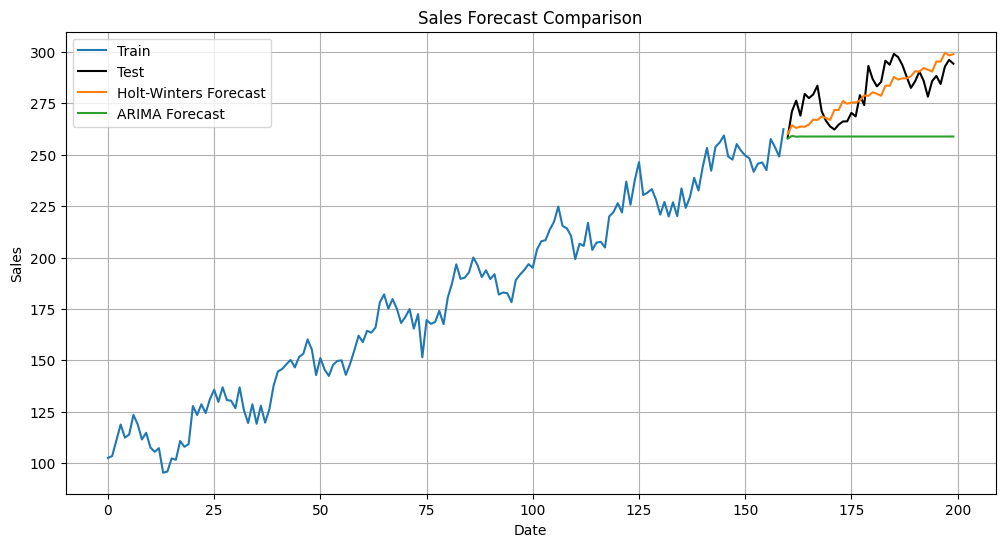

In [12]:
# ------------------------------------------------------------
# 12. Forecast comparison plot
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(train.index, train["Sales"], label="Train")
plt.plot(test.index, test["Sales"], label="Test", color="black")
plt.plot(test.index, hw_forecast, label="Holt-Winters Forecast")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast")
plt.title("Sales Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

**Sales Forecast Comparison Analysi**s

1. Purpose
   The purpose of this analysis is to compare the forecasting performance of the Holt-Winters model and the ARIMA model using the training and test datasets. This comparison helps determine which model better captures the underlying patterns in the data and produces more accurate predictions.

2. Train and Test Data Behavior
   The training data shows a clear upward trend with seasonal fluctuations, while the test data continues this pattern. The consistency between the training and test sets indicates that the underlying structure of the time series remains stable over time.

3. Holt-Winters Forecast Interpretation
   The Holt-Winters forecast closely follows the pattern of the test data. It captures both the upward trend and the seasonal fluctuations, producing predictions that align well with the actual values. This indicates that the model effectively incorporates both trend and seasonality.

4. ARIMA Forecast Interpretation
   The ARIMA forecast appears relatively flat compared to the test data. It does not capture the upward trend or the seasonal variations effectively. As a result, it underestimates the growth in sales and fails to reflect the dynamic behavior of the series.

5. Model Performance Comparison
   Visually, the Holt-Winters model provides a much better fit to the test data than the ARIMA model. The Holt-Winters predictions track the actual values more closely, while the ARIMA model deviates significantly. This suggests that Holt-Winters is more suitable for this dataset.

6. Ability to Capture Seasonality
   A key difference between the two models is their ability to handle seasonality. The Holt-Winters model explicitly incorporates seasonal components, allowing it to replicate the repeating patterns in the data. The ARIMA model used in this analysis does not include a seasonal component, which limits its effectiveness.

7. Limitations
   While Holt-Winters performs well in this case, it assumes that trend and seasonal patterns remain consistent over time. The ARIMA model, although less effective here, could potentially perform better if extended to include seasonal terms. Both models rely on historical patterns and may not account for external changes or unexpected events.

8. Business Implications
   From a business perspective, the Holt-Winters model provides more reliable forecasts, making it better suited for planning and decision-making. Accurate forecasts can support inventory management, staffing, and budgeting. The weaker performance of the ARIMA model highlights the importance of selecting models that align with the structure of the data, particularly when seasonality is present.


In [13]:
# ------------------------------------------------------------
# 13. Final model and next 12 months forecast
# ------------------------------------------------------------
final_model = ExponentialSmoothing(
    df["Sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

future_steps = 12
future_forecast = final_model.forecast(future_steps)

print("\nNext 12 Months Forecast:")
print(future_forecast)


Next 12 Months Forecast:
200    294.599427
201    295.599818
202    297.601553
203    299.178470
204    299.154027
205    297.575673
206    297.206832
207    301.892155
208    301.571955
209    306.516571
210    305.946321
211    305.872534
dtype: float64


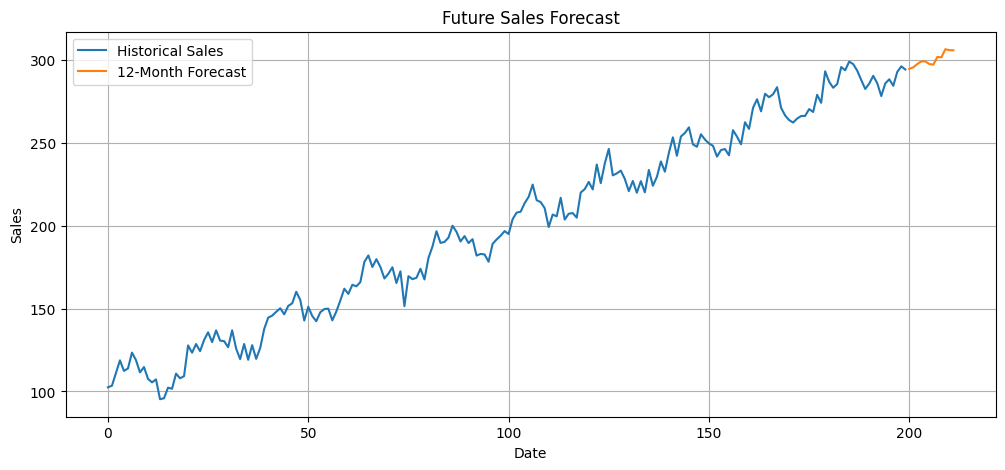

In [14]:
# ------------------------------------------------------------
# 14. Future forecast plot
# ------------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Sales"], label="Historical Sales")
plt.plot(future_forecast.index, future_forecast, label="12-Month Forecast")
plt.title("Future Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

Here is the formal write-up for the **Future Sales Forecast plot**, consistent with your previous sections.

---

Future Sales Forecast Analysis

1. Purpose
   The purpose of this analysis is to project future sales for the next 12 months using a forecasting model based on historical data. This helps estimate future demand and supports planning and decision-making.

2. Forecast Behavior
   The forecast shows a continuation of the upward trend observed in the historical data. Sales are expected to increase steadily over the forecast period, maintaining the growth pattern established in the past.

3. Alignment with Historical Data
   The forecast begins at the end of the historical series and follows a path that is consistent with previous trends. This indicates that the model has successfully learned the underlying structure of the data and is extending it into the future.

4. Seasonality in Forecast
   The forecast reflects the seasonal pattern present in the historical data, with expected fluctuations that mirror previous cycles. This suggests that the model accounts for recurring monthly variations in sales.

5. Trend Continuation
   The continued upward movement in the forecast indicates that the business is expected to maintain its growth trajectory. The absence of sharp declines suggests stability in future performance based on current trends.

6. Confidence in Forecast
   Because the forecast is based on a model that captures both trend and seasonality, it provides a reasonable estimate of future sales. However, forecasts become less certain further into the future and should be interpreted with caution.

7. Limitations
   The forecast assumes that past patterns will continue unchanged. It does not account for external factors such as economic changes, competition, or unexpected events. As a result, actual future sales may differ from the projected values.

8. Business Implications
   From a business perspective, the forecast indicates continued growth, which may require increased production, inventory, and staffing. The seasonal pattern allows for better planning of high-demand periods. These insights support strategic decisions related to budgeting, resource allocation, and long-term planning.


## SECTION 7: Comparison of Methods

The moving average and linear regression methods both identify an upward trend in sales, but they differ in how they represent the data. The moving average provides a smoothed curve that captures gradual changes and reduces noise, making it easier to see patterns such as seasonality and local fluctuations. In contrast, linear regression produces a straight line that summarizes the overall direction of the data but ignores seasonal effects.

The moving average is more effective for understanding short-term dynamics and identifying patterns over time, while regression is better suited for estimating long-term growth and making forecasts. In this analysis, the moving average provides a more detailed and realistic view of the data, whereas regression offers a simpler, more generalized trend.

Overall, the moving average is more appropriate for exploratory analysis, while linear regression is better for prediction and strategic planning.

## SECTION 8: Limitations

Both methods have limitations that must be considered when interpreting results. The moving average reduces noise but also lags behind the data, meaning it may respond slowly to sudden changes. It also removes some important information, such as extreme values or sharp shifts, which may be meaningful for decision-making.

Linear regression assumes a constant linear relationship, which may oversimplify real-world data. It ignores seasonality and is sensitive to outliers, which can distort the trend line. Additionally, regression assumes that past trends will continue into the future, which may not always be true in dynamic business environments.

Because of these limitations, it is important to use both methods together to gain a more complete understanding of the data.

## SECTION 9: Business Implications

From a business perspective, the analysis indicates that sales are steadily increasing over time, suggesting strong performance and growing demand. The presence of seasonality implies that certain periods consistently generate higher sales, which can inform inventory planning, staffing decisions, and marketing strategies.

The moving average helps identify stable growth trends, which can support long-term planning and resource allocation. Meanwhile, the regression model provides a basis for forecasting future sales, helping organizations make data-driven decisions.

However, decision-makers should be cautious when relying solely on these models, as they do not account for external factors such as market changes, competition, or economic conditions. Combining these insights with business context leads to more effective and informed strategies.